# Gene Embedding Pipeline

BioMart gene list → MyGene/UniProt sequence mapping → ESM-2 embeddings

**Split strategy:**
- **Part A (local):** BioMart + sequence mapping — just API calls, no GPU needed
- **Part B (cluster):** ESM-2 embedding generation — needs GPU (6+ GB VRAM)

Transfer `data/sequences/gene_to_sequence.pkl` (~15-25 MB) to cluster between parts.

### Output artifacts

| File | Size | What |
|------|------|------|
| `data/sequences/gene_to_sequence.pkl` | ~15-25 MB | {gene: amino_acid_sequence} |
| `data/embeddings/gene_to_embedding.pkl` | ~95-120 MB | {gene: 1280-dim numpy array} |

In [1]:
import sys
import logging
import pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

# Project root (assuming notebook is in notebooks/)
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# Output directories
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
SEQ_DIR = DATA_DIR / "sequences"
EMB_DIR = DATA_DIR / "embeddings"

for d in [RAW_DIR, SEQ_DIR, EMB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger(__name__)

---
# Part A: Sequence Mapping (run locally)

No GPU needed. Takes ~5-15 minutes (API rate limits).

## A1. Load protein-coding genes from BioMart

**Data provenance (not committed to git):**
- Source: [Ensembl BioMart](http://www.ensembl.org/biomart/martview), release 115 (GRCh38.p14)
- Downloaded: 2026-02-19
- Attributes: Gene stable ID, Gene name, Gene type, Gene description
- No filters applied (filtering to `protein_coding` done in code)
- File: `data/raw/mart_export.txt` (7 MB, 86K rows across all gene types)

In [4]:
BIOMART_FILE = RAW_DIR / "mart_export.txt"

from scipher.preprocess.gene_list import get_protein_coding_genes

gene_symbols, gene_descriptions = get_protein_coding_genes(BIOMART_FILE)
print(f"Protein-coding genes: {len(gene_symbols):,}")
print(f"With descriptions:    {len(gene_descriptions):,}")

01:39:57 [INFO] Loading protein-coding genes from BioMart...
01:39:57 [INFO] Loaded 19,477 protein-coding gene symbols from BioMart
01:39:57 [INFO]   - 19,477 genes have descriptions


Protein-coding genes: 19,477
With descriptions:    19,477


In [5]:
# BioMart gene type breakdown
df_biomart = pd.read_csv(BIOMART_FILE)
print(f"Total rows in BioMart export: {len(df_biomart):,}")
print(f"\nGene type distribution:")
print(df_biomart["Gene type"].value_counts().to_string())

Total rows in BioMart export: 86,369

Gene type distribution:
Gene type
lncRNA                                36490
protein_coding                        23262
processed_pseudogene                  10234
unprocessed_pseudogene                 2802
misc_RNA                               2418
snRNA                                  2094
miRNA                                  1945
transcribed_unprocessed_pseudogene     1801
transcribed_processed_pseudogene       1219
TEC                                    1084
snoRNA                                 1020
rRNA_pseudogene                         516
IG_V_pseudogene                         300
IG_V_gene                               229
transcribed_unitary_pseudogene          206
TR_V_gene                               160
unitary_pseudogene                       97
TR_J_gene                                93
rRNA                                     71
IG_D_gene                                64
scaRNA                                   51
TR_V

## A2. Map genes to protein sequences

Pipeline: gene symbol → MyGene.info → UniProt ID → UniProt REST → amino acid sequence

This calls external APIs and takes ~5-15 minutes. Results are cached to `gene_to_sequence.pkl`.

In [6]:
SEQ_CACHE = SEQ_DIR / "gene_to_sequence.pkl"

if SEQ_CACHE.exists():
    print(f"Loading cached sequences from {SEQ_CACHE}")
    with open(SEQ_CACHE, "rb") as f:
        gene_to_sequence = pickle.load(f)
    missing_genes = [g for g in gene_symbols if g not in gene_to_sequence]
else:
    from scipher.preprocess.gene_mapping import map_genes_to_sequences
    gene_to_sequence, missing_genes = map_genes_to_sequences(gene_symbols, gene_descriptions)

    with open(SEQ_CACHE, "wb") as f:
        pickle.dump(gene_to_sequence, f)
    print(f"Saved to {SEQ_CACHE} ({SEQ_CACHE.stat().st_size / 1024**2:.1f} MB)")

print(f"\nMapped:  {len(gene_to_sequence):,} genes")
print(f"Missing: {len(missing_genes):,} genes")
print(f"Success: {100 * len(gene_to_sequence) / len(gene_symbols):.1f}%")

01:40:11 [INFO] ============================================================
01:40:11 [INFO] Mapping genes to protein sequences
01:40:11 [INFO] ============================================================
01:40:11 [INFO] Querying MyGene.info for 19477 genes...
Querying MyGene:   0%|          | 0/195 [00:00<?, ?it/s]01:40:11 [WARNING] Input sequence provided is already in string format. No operation performed
01:40:11 [WARNING] Input sequence provided is already in string format. No operation performed
01:40:11 [INFO] querying 1-100 ...
01:40:12 [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
01:40:13 [INFO] Finished.
01:40:13 [WARNING] 3 input query terms found dup hits:	[('PRAMEF22', 2), ('OR5G3', 2), ('ORAI1', 2)]
Querying MyGene:   1%|          | 1/195 [00:02<08:34,  2.65s/it]01:40:13 [WARNING] Input sequence provided is already in string format. No operation performed
01:40:13 [WARNING] Input sequence provided is already in string format. No operation perf

Saved to /mnt/c/Users/zhaoj/projects/scipher/data/sequences/gene_to_sequence.pkl (10.9 MB)

Mapped:  19,308 genes
Missing: 169 genes
Success: 99.1%


## A3. Sequence analysis

In [7]:
regular = {k: v for k, v in gene_to_sequence.items() if isinstance(v, str)}
readthrough = {k: v for k, v in gene_to_sequence.items() if isinstance(v, tuple)}

print(f"Regular genes:     {len(regular):,}")
print(f"Readthrough genes: {len(readthrough):,}")

Regular genes:     19,207
Readthrough genes: 101


In [8]:
# Sequence length distribution
regular_lengths = np.array([len(seq) for seq in regular.values()])

print("Protein sequence length stats (regular genes):")
print(f"  Mean:   {regular_lengths.mean():.0f} aa")
print(f"  Median: {np.median(regular_lengths):.0f} aa")
print(f"  Std:    {regular_lengths.std():.0f} aa")
print(f"  Min:    {regular_lengths.min()} aa")
print(f"  Max:    {regular_lengths.max():,} aa")

# Percentiles
for p in [25, 50, 75, 90, 95, 99]:
    print(f"  P{p:02d}:    {np.percentile(regular_lengths, p):.0f} aa")

Protein sequence length stats (regular genes):
  Mean:   578 aa
  Median: 430 aa
  Std:    608 aa
  Min:    25 aa
  Max:    34,350 aa
  P25:    271 aa
  P50:    430 aa
  P75:    690 aa
  P90:    1101 aa
  P95:    1490 aa
  P99:    2784 aa


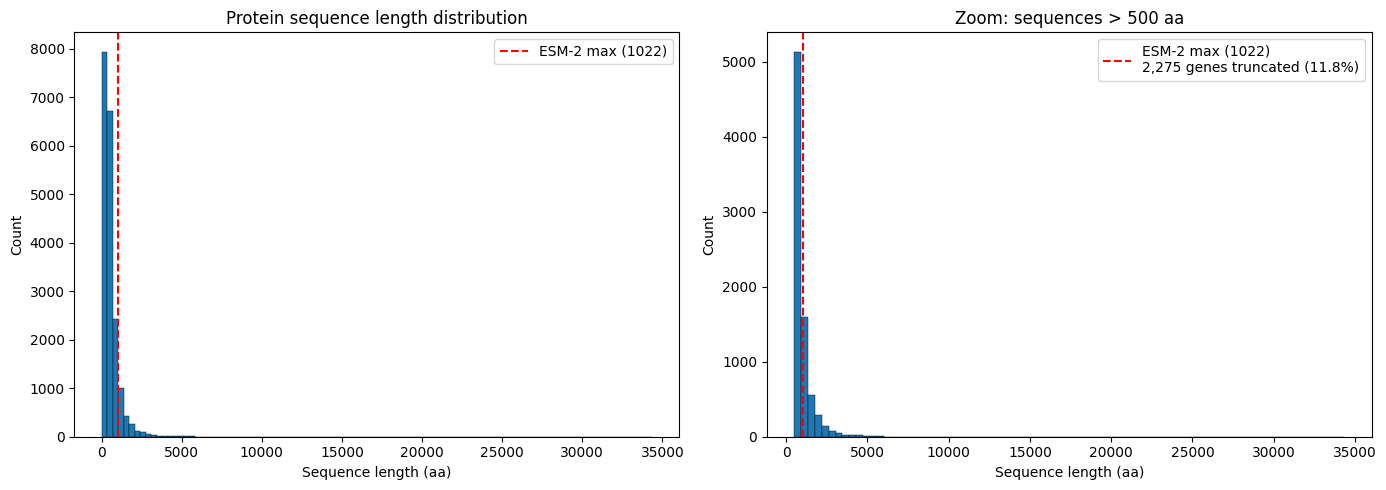


Truncation: 2,275 / 19,207 sequences (11.8%) exceed 1022 residues


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(regular_lengths, bins=100, edgecolor="black", linewidth=0.3)
axes[0].axvline(1022, color="red", linestyle="--", label=f"ESM-2 max (1022)")
axes[0].set_xlabel("Sequence length (aa)")
axes[0].set_ylabel("Count")
axes[0].set_title("Protein sequence length distribution")
axes[0].legend()

# Zoom into truncation region
n_truncated = (regular_lengths > 1022).sum()
pct_truncated = 100 * n_truncated / len(regular_lengths)
axes[1].hist(regular_lengths[regular_lengths > 500], bins=80, edgecolor="black", linewidth=0.3)
axes[1].axvline(1022, color="red", linestyle="--", label=f"ESM-2 max (1022)\n{n_truncated:,} genes truncated ({pct_truncated:.1f}%)")
axes[1].set_xlabel("Sequence length (aa)")
axes[1].set_ylabel("Count")
axes[1].set_title("Zoom: sequences > 500 aa")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nTruncation: {n_truncated:,} / {len(regular_lengths):,} sequences ({pct_truncated:.1f}%) exceed 1022 residues")

In [10]:
# Longest proteins (will be truncated the most)
sorted_by_length = sorted(regular.items(), key=lambda x: len(x[1]), reverse=True)

print("Top 20 longest proteins (most truncation):")
print(f"{'Gene':<20} {'Length':>8} {'Lost':>8} {'% Lost':>8}")
print("-" * 48)
for gene, seq in sorted_by_length[:20]:
    length = len(seq)
    lost = max(0, length - 1022)
    pct = 100 * lost / length if lost > 0 else 0
    print(f"{gene:<20} {length:>8,} {lost:>8,} {pct:>7.1f}%")

Top 20 longest proteins (most truncation):
Gene                   Length     Lost   % Lost
------------------------------------------------
TTN                    34,350   33,328    97.0%
MUC16                  14,507   13,485    93.0%
SYNE1                   8,797    7,775    88.4%
NEB                     8,525    7,503    88.0%
MUC19                   8,384    7,362    87.8%
OBSCN                   7,968    6,946    87.2%
DST                     7,570    6,548    86.5%
MACF1                   7,388    6,366    86.2%
FSIP2                   6,907    5,885    85.2%
SYNE2                   6,885    5,863    85.2%
ADGRV1                  6,306    5,284    83.8%
AHNAK                   5,890    4,868    82.6%
AHNAK2                  5,795    4,773    82.4%
MUC5B                   5,762    4,740    82.3%
MUC5AC                  5,654    4,632    81.9%
HMCN1                   5,635    4,613    81.9%
MDN1                    5,596    4,574    81.7%
KMT2D                   5,537    4,515    81

In [11]:
# Unmapped genes: what kind are they?
patterns = Counter()
examples = {}
for g in missing_genes:
    if g.startswith("LOC"):
        cat = "LOC* (uncharacterized locus)"
    elif g.startswith("LINC"):
        cat = "LINC* (lncRNA, possibly mislabeled protein_coding)"
    elif g.startswith("MIR") and not g.startswith("MIRLET"):
        cat = "MIR* (microRNA host gene)"
    elif "-" in g and not g.startswith("HLA-"):
        cat = "Hyphenated (readthrough / antisense)"
    elif g.startswith(("FAM", "C")) and any(c.isdigit() for c in g):
        cat = "FAM*/C*orf* (uncharacterized family)"
    elif g.startswith("SNORD") or g.startswith("SNORA") or g.startswith("SCARNA"):
        cat = "snoRNA host gene"
    else:
        cat = "Other"
    patterns[cat] += 1
    examples.setdefault(cat, []).append(g)

print(f"Unmapped genes by category ({len(missing_genes)} total):")
print(f"{'Category':<50} {'Count':>6}  Examples")
print("-" * 90)
for cat, count in patterns.most_common():
    ex = ", ".join(examples[cat][:5])
    print(f"{cat:<50} {count:>6}  {ex}")

Unmapped genes by category (169 total):
Category                                            Count  Examples
------------------------------------------------------------------------------------------
Other                                                 135  MAFIP, PRAMEF9, OR9G9, OR5G3, WASH6P
FAM*/C*orf* (uncharacterized family)                   23  CNTNAP3C, CCDC168, C18orf21, FAM210B, FAM246C
Hyphenated (readthrough / antisense)                    6  KRTAP6-3, OR4M2-OT1, KBTBD11-OT1, SMIM10L2B-AS1, ERVK3-1
LINC* (lncRNA, possibly mislabeled protein_coding)      5  LINC02218, LINC02203, LINC01556, LINC03051, LINC03040


In [12]:
# Size estimate for the embedding pickle
n_genes = len(gene_to_sequence)
embed_dim = 1280  # ESM-2 650M
size_mb = n_genes * embed_dim * 4 / (1024 ** 2)  # float32
print(f"Expected gene_to_embedding.pkl size:")
print(f"  {n_genes:,} genes x {embed_dim} dim x 4 bytes = {size_mb:.0f} MB (raw arrays)")
print(f"  With pickle overhead: ~{size_mb * 1.15:.0f} MB")
print(f"\nSequence cache size: {SEQ_CACHE.stat().st_size / 1024**2:.1f} MB")

Expected gene_to_embedding.pkl size:
  19,308 genes x 1280 dim x 4 bytes = 94 MB (raw arrays)
  With pickle overhead: ~108 MB

Sequence cache size: 10.9 MB


---
# Part B: ESM-2 Embedding (run on cluster)

**Requirements:**
- GPU with 6+ GB VRAM (RTX 3090/4090, A100, etc.)
- `fair-esm` installed: `pip install fair-esm`
- `data/sequences/gene_to_sequence.pkl` transferred from local

**Expected runtime:** ~30-60 min on a modern GPU, ~2-4 hours on CPU.

In [ ]:
# Load sequences (on cluster, after transfer)
import pickle
from pathlib import Path

SEQ_CACHE = Path("../data/sequences/gene_to_sequence.pkl")  # adjust path if needed
EMB_CACHE = Path("../data/embeddings/gene_to_embedding.pkl")
EMB_CACHE.parent.mkdir(parents=True, exist_ok=True)

with open(SEQ_CACHE, "rb") as f:
    gene_to_sequence = pickle.load(f)

print(f"Loaded {len(gene_to_sequence):,} gene sequences")
print(f"  Regular:     {sum(1 for v in gene_to_sequence.values() if isinstance(v, str)):,}")
print(f"  Readthrough: {sum(1 for v in gene_to_sequence.values() if isinstance(v, tuple)):,}")

In [ ]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_mem / 1024**3:.1f} GB")

In [ ]:
# Configuration
MODEL_NAME = "esm2_t33_650M_UR50D"  # 1280-dim, ~2.5 GB
BATCH_SIZE = 8    # reduce to 4 if OOM, increase to 16-32 if you have VRAM to spare
MAX_LENGTH = 1022  # ESM-2 token limit minus BOS/EOS

In [ ]:
import sys
import time

# Add project root to path
sys.path.insert(0, str(Path("..").resolve()))

from scipher.embedders.gene_embeddings.esm2 import ESM2Embedder

embedder = ESM2Embedder(model_name=MODEL_NAME, max_length=MAX_LENGTH)

t0 = time.time()
gene_to_embedding = embedder.generate_all_embeddings(
    gene_to_sequence,
    readthrough_strategy="concat",
    cache_path=EMB_CACHE,
    batch_size=BATCH_SIZE,
)
elapsed = time.time() - t0

m, s = divmod(int(elapsed), 60)
print(f"\nDone in {m}m {s}s")
print(f"Throughput: {len(gene_to_embedding) / elapsed:.1f} genes/sec")
print(f"Saved to {EMB_CACHE} ({EMB_CACHE.stat().st_size / 1024**2:.1f} MB)")

In [ ]:
# Quick sanity check on the embeddings
import numpy as np

all_embeddings = np.array(list(gene_to_embedding.values()))
print(f"Embedding matrix: {all_embeddings.shape}")
print(f"Dtype: {all_embeddings.dtype}")
print(f"\nPer-dimension stats:")
print(f"  Mean of means:  {all_embeddings.mean():.4f}")
print(f"  Mean of stds:   {all_embeddings.std(axis=0).mean():.4f}")
print(f"  Any NaN:        {np.isnan(all_embeddings).any()}")
print(f"  Any Inf:        {np.isinf(all_embeddings).any()}")

# Check a few norms
norms = np.linalg.norm(all_embeddings, axis=1)
print(f"\nL2 norm stats:")
print(f"  Mean: {norms.mean():.2f}")
print(f"  Std:  {norms.std():.2f}")
print(f"  Min:  {norms.min():.2f}")
print(f"  Max:  {norms.max():.2f}")

In [ ]:
# Spot-check: are similar proteins getting similar embeddings?
from scipy.spatial.distance import cosine

test_pairs = [
    # Should be similar (same family)
    ("BRCA1", "BRCA2"),
    ("TP53", "TP63"),
    ("KRAS", "NRAS"),
    ("CDK4", "CDK6"),
    # Should be dissimilar (unrelated)
    ("TP53", "GAPDH"),
    ("BRCA1", "MYC"),
]

print(f"{'Gene A':<10} {'Gene B':<10} {'Cosine sim':>12}  Expected")
print("-" * 50)
for g1, g2 in test_pairs:
    if g1 in gene_to_embedding and g2 in gene_to_embedding:
        sim = 1 - cosine(gene_to_embedding[g1], gene_to_embedding[g2])
        expected = "similar" if test_pairs.index((g1, g2)) < 4 else "dissimilar"
        print(f"{g1:<10} {g2:<10} {sim:>12.4f}  {expected}")
    else:
        missing = [g for g in (g1, g2) if g not in gene_to_embedding]
        print(f"{g1:<10} {g2:<10} {'N/A':>12}  (missing: {', '.join(missing)})")